# 📉 End-to-End ML Project — Customer Churn Prediction Service

> **What you'll build:** a real churn model on the IBM Telco dataset that decides **who should get a retention offer** by maximizing expected profit, then ship it the way teams do at work: a Python package, a FastAPI service, pytest tests with a model-quality gate, a Docker image, a CI pipeline, and a monitoring plan.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +3 hours to extend the project and rehearse the pitch |
| **Prerequisites** | [Scikit-Learn](../03_Classical_Machine_Learning/02_Scikit_Learn.ipynb) · [Gradient Boosting](../03_Classical_Machine_Learning/03_Gradient_Boosting.ipynb) · [FastAPI](../10_Model_Serving/01_FastAPI.ipynb) (helpful: [Docker and CI/CD](../10_Model_Serving/02_Docker_and_CI_CD.ipynb)) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · pandas 3.0 · FastAPI 0.141 · Pydantic 2.13 · uvicorn 0.52 · pytest 9 · Docker 28 |
| **Interview relevance** | ⭐⭐⭐ High — "walk me through a project end to end", threshold/metric choice, leakage, calibration, serving, testing, monitoring |

**The project folder:** everything this notebook runs lives in [`churn_service/`](churn_service/README.md) next to it — a repository you could push to GitHub as-is. The notebook imports that package; it does not copy its code.

## 🤔 Problem & Business Goal

A telecom company loses customers every month. **Churn** means a customer cancels their contract. The retention team can call a customer and offer a discount, but every offer costs money, and most customers were never going to leave.

So the real question is not *"will this customer churn?"* but:

> **Which customers should receive a retention offer this month so that the company makes the most money?**

That changes how we build and judge the model:

| Typical tutorial | This project |
|---|---|
| maximize accuracy | maximize **expected profit** of the offer campaign |
| threshold 0.5 | threshold **chosen on a validation split** from a cost model |
| one test score | test set used **once**, with **confidence intervals** |
| model in a notebook | package + API + tests + Docker + CI + monitoring |

**Success criteria (decided before modelling):**
1. Expected profit per 1,000 customers beats the two simple policies: *contact nobody* ($0) and *contact everyone*.
2. Test ROC-AUC ≥ 0.80 (a quality floor enforced by an automated test, so a broken retrain can't ship).
3. The service validates inputs, reports its model version, and uses exactly the threshold saved with the model.

**Key terms.** *ROC-AUC*: the probability that a random churner gets a higher score than a random non-churner (0.5 = coin flip, 1.0 = perfect ranking). *Threshold*: the probability above which we act. *Calibration*: whether "30% risk" really means 30 out of 100 such customers churn.

## 🗺️ Architecture

```mermaid
flowchart LR
    A["IBM Telco CSV (GitHub)"] -->|"download + SHA-256 check"| B["data.py: validate + clean"]
    B --> C["stratified split: train / validation / test"]
    C -->|train| D["train.py: CV logistic regression vs gradient boosting"]
    D --> E["fitted pipeline"]
    C -->|validation| F["business.py: profit-maximizing threshold"]
    E --> F
    C -->|"test (once)"| G["evaluate.py: bootstrap CIs + slices"]
    F --> G
    G --> H[("artifacts/: model.joblib, metadata.json, reference_stats.json, MODEL_CARD.md")]
    H --> I["api.py: FastAPI /predict, /predict/batch, /ready"]
    I --> J["Docker image"]
    K["tests/ + CI pipeline"] --> J
    H -.-> L["monitoring.py: PSI drift report"]
    I -.->|"request logs"| L
```

| Folder / file | Role |
|---|---|
| `src/churn_service/config.py` | paths, dataset URL + checksum, **business assumptions** |
| `data.py` · `features.py` · `business.py` | data validation and splits · feature pipeline · profit metric |
| `train.py` · `evaluate.py` · `predict.py` | model comparison + CLI · metrics, CIs, model card · save/load |
| `schemas.py` · `api.py` · `monitoring.py` | Pydantic contract · FastAPI app · drift statistics |
| `tests/` · `Dockerfile` · `ci/github-actions.yml` | pytest suite · container · CI example |

The **same** cleaning function and the **same** pipeline object are used in training and in the API. That is how we avoid *training/serving skew* (the model seeing differently prepared data in production than in training).

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, and restart the kernel.

- **No installation of the project.** We add `churn_service/src` to `sys.path`, so `import churn_service` uses the files in the folder. (In your own repo you would run `uv pip install -e ".[dev]"`.)
- **Downloads:** the dataset (~1 MB) once, into `churn_service/data/` (git-ignored). The Docker section pulls `python:3.12-slim` and a small `uv` image if you don't have them.
- **Files written:** `churn_service/data/` and `churn_service/artifacts/` (both git-ignored, recreated by training) and scratch files in `_outputs/churn/`.
- **Docker** is optional: if it isn't running, the container cells print a skip message with the exact commands.
- `run()` prints a shell command and its output like a terminal. `check()` gives exercise feedback: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "scikit-learn>=1.9,<2" "pandas>=3.0,<4" "fastapi>=0.141,<1" "pydantic>=2.13,<3" "uvicorn>=0.52,<1" "httpx>=0.28" "pytest>=9" pyyaml matplotlib

import importlib.metadata as md
import inspect
import json
import math
import os
import re
import shutil
import signal
import socket
import subprocess
import sys
import time
from dataclasses import replace
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display
from sklearn.base import clone

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR / "churn_service"
OUTPUT_DIR = NOTEBOOK_DIR / "_outputs" / "churn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_DIR / "src"))          # import the project package without installing it

import churn_service  # noqa: E402
from churn_service import config as cfg  # noqa: E402
from churn_service.business import best_threshold, break_even_probability, expected_profit, profit_curve, profit_per_1000  # noqa: E402
from churn_service.data import (FEATURE_COLUMNS, clean, download_raw, file_sha256, load_raw, make_splits,  # noqa: E402
                                parse_total_charges, save_splits, split_features_target, validate_raw)
from churn_service.evaluate import bootstrap_metrics, calibration_table, metric_row, permutation_importance_table  # noqa: E402
from churn_service.features import ENGINEERED_FEATURES, add_features  # noqa: E402
from churn_service.monitoring import drift_report, reference_statistics  # noqa: E402
from churn_service.predict import ChurnModel, save_artifacts  # noqa: E402
from churn_service.schemas import COLUMN_NAMES, EXAMPLE_CUSTOMER  # noqa: E402
from churn_service.train import build_metadata, candidate_models, cross_validate_models, evaluation_slices, select_model  # noqa: E402

for pkg in ["scikit-learn", "pandas", "numpy", "fastapi", "pydantic", "uvicorn", "pytest"]:
    print(f"{pkg} {md.version(pkg)}", end=" | ")
print(f"Python {sys.version.split()[0]} | churn_service {churn_service.__version__}")

pd.set_option("display.precision", 4)
DOCKER, UV = shutil.which("docker"), shutil.which("uv")


def rel(text):
    """Show paths relative to this notebook and never print the local home folder."""
    text = str(text).replace(str(NOTEBOOK_DIR) + os.sep, "").replace(str(NOTEBOOK_DIR), ".")
    return text.replace(str(Path.home()), "~")


def run(cmd, cwd=PROJECT_DIR, env=None, max_lines=30, timeout=900):
    """Run a command like a terminal: `$ command`, the last `max_lines` of output, exit code and time."""
    names = {sys.executable: "python", DOCKER: "docker", UV: "uv"}
    print("$", rel(" ".join(names.get(str(c), str(c)) for c in cmd)))
    start = time.perf_counter()
    result = subprocess.run([str(c) for c in cmd], cwd=cwd, env={**os.environ, **(env or {})}, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, timeout=timeout)
    lines = re.sub(r"\x1b\[[0-9;]*m", "", result.stdout).rstrip().splitlines()
    if len(lines) > max_lines:
        print(f"  … ({len(lines) - max_lines} earlier lines hidden)")
        lines = lines[-max_lines:]
    for line in lines:
        print("  " + rel(line))
    result.seconds = time.perf_counter() - start
    print(f"  [exit code {result.returncode} · {result.seconds:.1f} s]")
    return result


def show_source(obj, max_lines=60):
    """Print the real source code of a function/class from the project package."""
    lines = inspect.getsource(obj).splitlines()
    print(f"# {rel(inspect.getsourcefile(obj))}")
    print("\n".join(lines[:max_lines]) + (f"\n# … {len(lines) - max_lines} more lines" if len(lines) > max_lines else ""))


def free_port():
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]


class UvicornServer:
    """`python -m uvicorn target` in a background process on a free port; stopped with SIGTERM on exit."""

    def __init__(self, target, cwd, env=None, ready_path="/ready"):
        self.target, self.cwd, self.ready_path = target, cwd, ready_path
        self.port = free_port()
        self.base_url = f"http://127.0.0.1:{self.port}"
        self.env = {**os.environ, "PYTHONUNBUFFERED": "1", **(env or {})}
        self.log_path = OUTPUT_DIR / f"uvicorn_{self.port}.log"

    def __enter__(self):
        self._log = open(self.log_path, "w")
        self.proc = subprocess.Popen([sys.executable, "-m", "uvicorn", self.target, "--host", "127.0.0.1", "--port", str(self.port)],
                                     cwd=self.cwd, env=self.env, stdout=self._log, stderr=subprocess.STDOUT)
        start = time.perf_counter()
        while time.perf_counter() - start < 60:
            if self.proc.poll() is not None:
                raise RuntimeError(f"uvicorn exited early:\n{rel(self.log_path.read_text())[-2000:]}")
            try:
                if httpx.get(self.base_url + self.ready_path, timeout=1).status_code == 200:
                    self.startup_seconds = time.perf_counter() - start
                    return self
            except httpx.TransportError:
                pass
            time.sleep(0.1)
        self.__exit__()
        raise TimeoutError("server not ready after 60 s")

    def __exit__(self, *exc):
        if self.proc.poll() is None:
            self.proc.send_signal(signal.SIGTERM)          # graceful shutdown, like `docker stop`
            try:
                self.proc.wait(timeout=20)
            except subprocess.TimeoutExpired:
                self.proc.kill()
        self._log.close()

    def log_text(self):
        return rel(self.log_path.read_text())


def check(name, got, expected, hint="", rel_tol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (int, float, np.number)) and not isinstance(expected, bool):
        ok = isinstance(got, (int, float, np.number)) and math.isclose(float(got), float(expected), rel_tol=rel_tol, abs_tol=1e-9)
    else:
        ok = got == expected
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")


print("project folder:", rel(PROJECT_DIR), "| docker:", "found" if DOCKER else "not installed", "| uv:", "found" if UV else "not installed")

scikit-learn 1.9.1 | pandas 3.0.5 | numpy 2.5.3 | fastapi 0.141.1 | pydantic 2.13.5 | uvicorn 0.52.4 | pytest 9.1.1 | Python 3.12.11 | churn_service 1.0.0
project folder: churn_service | docker: found | uv: found


## Step 1. Frame the Decision as Money 🟢

Every prediction leads to one of four outcomes. We attach money to each one. The numbers below are **assumptions** (they are not in the dataset), so they live in one clearly named place, `config.BusinessAssumptions`, where a finance or retention team can change them:

| | customer would churn | customer would stay |
|---|---|---|
| **we contact** (offer sent) | true positive: they stay with probability `acceptance_rate` → we keep `MonthlyCharges × months_retained`, minus `offer_cost` | false positive: we pay `offer_cost` for nothing |
| **we don't contact** | false negative: they leave (same as today → $0 change) | true negative: $0 |

Measuring everything **relative to doing nothing** keeps the formula simple: only contacted customers change the profit.

For one customer with churn probability $p$, contacting pays off on average when

$$p \cdot \text{acceptance} \cdot \text{MonthlyCharges} \cdot \text{months} > \text{offer cost} \quad\Longleftrightarrow\quad p > \frac{\text{offer cost}}{\text{acceptance} \cdot \text{MonthlyCharges} \cdot \text{months}}$$

This is the **break-even probability**. It is only trustworthy if $p$ is *calibrated*, which we check in Step 8.

In [2]:
assumptions = cfg.BusinessAssumptions()
print("ASSUMPTIONS (replace with real numbers):", assumptions)
show_source(expected_profit)

examples = pd.DataFrame({"monthly_charges": [20.0, 70.0, 110.0]})
examples["value_if_saved"] = assumptions.acceptance_rate * examples["monthly_charges"] * assumptions.months_retained
examples["break_even_p"] = [break_even_probability(m, assumptions) for m in examples["monthly_charges"]]
print(examples.round(3).to_string(index=False))
cheap, pricey = examples["break_even_p"].iloc[0], examples["break_even_p"].iloc[-1]
print(f"\n→ a $20/month customer is worth contacting only above {cheap:.0%} churn risk"
      + (" (never: above 100%)" if cheap > 1 else "") + f"; a $110/month customer already above {pricey:.0%}.")

ASSUMPTIONS (replace with real numbers): BusinessAssumptions(offer_cost=60.0, acceptance_rate=0.35, months_retained=12)
# churn_service/src/churn_service/business.py
def expected_profit(y_true, contact, monthly_charges, assumptions: BusinessAssumptions) -> float:
    """Total expected profit (USD) versus doing nothing.

    Contacting a real churner:  acceptance_rate × monthly_charges × months_retained − offer_cost
    Contacting a non-churner:   − offer_cost (they would have stayed anyway)
    Not contacting anyone:      0
    """
    y_true = np.asarray(y_true, dtype=float)
    contact = np.asarray(contact, dtype=float)
    value_if_saved = assumptions.acceptance_rate * np.asarray(monthly_charges, dtype=float) * assumptions.months_retained
    return float(np.sum(contact * (y_true * value_if_saved - assumptions.offer_cost)))
 monthly_charges  value_if_saved  break_even_p
            20.0            84.0         0.714
            70.0           294.0         0.204
           110.0    

Two takeaways before touching any model:
- The right threshold depends on **money**, not on the model. Change the offer cost and the best threshold moves.
- One global threshold is a simplification: high-paying customers justify lower thresholds. We keep one threshold (simple to explain, audit, and serve) and list per-customer value ranking as a stretch goal.

### ✍️ Your Turn

At which monthly charge is the break-even churn probability **exactly 50%** under the default assumptions? Solve the formula for `MonthlyCharges`.

In [3]:
charge_for_50_percent = None  # TODO: offer_cost / (0.5 × acceptance_rate × months_retained)
check("charge_for_50_percent", charge_for_50_percent, assumptions.offer_cost / (0.5 * assumptions.acceptance_rate * assumptions.months_retained),
      hint="Set p = 0.5 in p × acceptance × charge × months = offer_cost and solve for charge.")

⏳ charge_for_50_percent: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
charge_for_50_percent = assumptions.offer_cost / (0.5 * assumptions.acceptance_rate * assumptions.months_retained)
print(f"${charge_for_50_percent:.2f} per month")
check("charge_for_50_percent", charge_for_50_percent, assumptions.offer_cost / (0.5 * assumptions.acceptance_rate * assumptions.months_retained))
```
</details>

> 💡 **Interview angle:** "Why not just use accuracy or F1?" — they treat every mistake as equally bad. Here a missed churner costs lost revenue and an unnecessary offer costs $60, so I turned the confusion matrix into dollars and chose the threshold that maximizes expected profit.

## Step 2. Load the Data and Validate It 🟢

**Dataset:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d) — 7,043 fictional customers of a telecom company, published by IBM under the Apache-2.0 license. One row per customer: demographics, services, contract, billing, and whether they left in the last month (`Churn`).

**Why validate?** A model trained on broken data fails *silently*: it still produces numbers. Real pipelines check every new batch against a **schema** (columns, types, allowed values, ranges) plus **business rules** before training. Errors stop the pipeline; warnings document known quirks.

`download_raw` also checks the file's **SHA-256** checksum, so if the upstream file ever changes, training stops instead of quietly producing a different model.

In [4]:
raw_path = download_raw(cfg.data_dir() / "raw" / "telco_customer_churn.csv")
print(f"{rel(raw_path)} | {raw_path.stat().st_size / 1e6:.2f} MB | sha256 matches config: {file_sha256(raw_path) == cfg.DATA_SHA256}")
raw = load_raw(raw_path)
print("shape:", raw.shape)
print(raw.dtypes.astype(str).value_counts().to_string())
raw.head(3)

churn_service/data/raw/telco_customer_churn.csv | 0.97 MB | sha256 matches config: True
shape: (7043, 21)
str        18
int64       2
float64     1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [5]:
report = validate_raw(raw)
print(report)
report.raise_if_failed()

blank_rows = raw[raw["TotalCharges"].str.strip() == ""]
print(f"\nThe quirk: {len(blank_rows)} rows have TotalCharges = ' ' (a space). Their tenure values: {sorted(blank_rows['tenure'].unique())}")
blank_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head(4)

✅ passed: 7,043 rows, 0 errors, 1 warnings
  WARNING TotalCharges: 11 blank values, all with tenure == 0 (not billed yet) → cleaned to 0.0

The quirk: 11 rows have TotalCharges = ' ' (a space). Their tenure values: [np.int64(0)]


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No


`TotalCharges` is text because of those blanks — `pd.to_numeric` would fail on it. Every blank belongs to a customer with `tenure == 0`: they signed up but haven't been billed yet. So the honest fix is **0.0**, not the column mean. We encode that rule in `clean()`, and the validator turns a blank with `tenure > 0` into an **error** (that would be a genuinely broken record).

Now let's prove the validator catches real problems by corrupting a copy of the data:

In [6]:
broken = raw.head(300).copy()
broken.loc[0, "Contract"] = "Monthly"                                   # a category the model has never seen
broken.loc[1, "tenure"] = -5                                            # impossible value
no_internet_row = broken.index[broken["InternetService"].eq("No")][0]
broken.loc[no_internet_row, "StreamingTV"] = "Yes"                      # streams TV without internet
broken.loc[3, "TotalCharges"] = " "                                     # blank for a long-standing customer
broken = pd.concat([broken, broken.head(1)], ignore_index=True)          # duplicate customer
print(validate_raw(broken))

clean_df = clean(raw)
print(f"\nafter clean(): TotalCharges dtype {clean_df['TotalCharges'].dtype}, missing {int(clean_df['TotalCharges'].isna().sum())}, "
      f"new customers set to 0.0: {int((clean_df['tenure'].eq(0) & clean_df['TotalCharges'].eq(0)).sum())}")

❌ failed: 301 rows, 5 errors, 0 warnings
  ERROR   1 duplicate customerID values
  ERROR   Contract: unexpected values ['Monthly']
  ERROR   tenure: 1 values outside [0, 120]
  ERROR   TotalCharges: 1 missing/non-numeric values for customers with tenure > 0
  ERROR   StreamingTV: 1 rows inconsistent with InternetService

after clean(): TotalCharges dtype float64, missing 0, new customers set to 0.0: 11


### ✍️ Your Turn

Using `clean_df`, count the customers whose `TotalCharges` differs from `tenure × MonthlyCharges` by **more than 10%** (only customers with `tenure > 0`). These are customers whose price changed over time.

In [7]:
n_price_changed = None  # TODO: ratio = TotalCharges / (tenure × MonthlyCharges); count |ratio − 1| > 0.10 among tenure > 0
billed = clean_df[clean_df["tenure"] > 0]
check("n_price_changed", n_price_changed, int(((billed["TotalCharges"] / (billed["tenure"] * billed["MonthlyCharges"]) - 1).abs() > 0.10).sum()),
      hint="Filter tenure > 0 first, then build the ratio and use (ratio - 1).abs() > 0.10 with .sum().")

⏳ n_price_changed: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
billed = clean_df[clean_df["tenure"] > 0]
ratio = billed["TotalCharges"] / (billed["tenure"] * billed["MonthlyCharges"])
n_price_changed = int(((ratio - 1).abs() > 0.10).sum())
print(f"{n_price_changed} of {len(billed)} billed customers ({n_price_changed / len(billed):.1%})")
check("n_price_changed", n_price_changed, int(((billed["TotalCharges"] / (billed["tenure"] * billed["MonthlyCharges"]) - 1).abs() > 0.10).sum()))
```
</details>

> 💡 **Interview angle:** "How do you make a training pipeline robust to bad data?" — schema + business-rule validation that fails fast (types, allowed categories, ranges, cross-column consistency, duplicates), checksums on inputs, and the same cleaning code in training and serving. Tools like Pandera or Great Expectations do this at scale; the idea is identical.

## Step 3. Split Once, Before Looking Closer 🟢

**Leakage** is when information from the data you evaluate on sneaks into training, so scores look better than reality. The safest habit: **split first**, then explore and model only on the training part.

| split | share | used for |
|---|---|---|
| train | 60% | exploration, feature decisions, cross-validation, fitting |
| validation | 20% | choosing the threshold, checking calibration, explainability |
| test | 20% | **one** final, honest estimate — nothing is tuned on it |

The split is **stratified** on `Churn` (every split keeps the ~26.5% churn rate). The dataset has no dates, so a time-based split isn't possible; with real data you'd train on older months and test on later ones. Each split is saved to CSV and its SHA-256 goes into the model metadata, so we can always prove which data a model saw.

In [8]:
splits = make_splits(clean_df, seed=cfg.SEED)
split_hashes = save_splits(splits, cfg.data_dir() / "splits")
split_summary = pd.DataFrame({name: {"rows": len(frame), "churn rate": frame["Churn"].eq("Yes").mean(), "sha256": split_hashes[name][:12] + "…"}
                              for name, frame in splits.items()}).T
print(split_summary.to_string())

ids = {name: set(frame["customerID"]) for name, frame in splits.items()}
assert not (ids["train"] & ids["validation"] or ids["train"] & ids["test"] or ids["validation"] & ids["test"])
print("✅ no customer appears in two splits")

X_train, y_train = split_features_target(splits["train"])
X_val, y_val = split_features_target(splits["validation"])
X_test, y_test = split_features_target(splits["test"])        # 🔒 locked until the 📏 Evaluation section
print(f"{X_train.shape[1]} input columns: {FEATURE_COLUMNS}")

            rows churn rate         sha256
train       4225     0.2653  839ca46c82e6…
validation  1409     0.2654  d0910eb490bb…
test        1409     0.2654  097f92f153d9…
✅ no customer appears in two splits
19 input columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


> 💡 **Interview angle:** "Why three splits instead of train/test?" — every decision you make by looking at a score (model choice, threshold, calibration method) *fits* that data a little. The validation set absorbs those decisions so the test set stays an unbiased final estimate.

## Step 4. Concise EDA on the Training Split 🟢

**EDA** (exploratory data analysis) here has one job: find signals and risks that shape modelling decisions. We only look at the **training** split.

                churn_rate  customers
Contract                             
Month-to-month       0.431       2326
One year             0.108        865
Two year             0.025       1034 

                 churn_rate  customers
InternetService                       
Fiber optic           0.423       1843
DSL                   0.187       1474
No                    0.073        908 

                           churn_rate  customers
PaymentMethod                                   
Electronic check                0.456       1410
Mailed check                    0.195        980
Bank transfer (automatic)       0.162        926
Credit card (automatic)         0.151        909 

FINDING 1: month-to-month churn 43.1% vs two-year 2.5% (17× higher)
FINDING 2: churn in the first 6 months 52.3% vs after 4 years 9.6%
FINDING 3: median monthly charge — churners $79.75 vs stayers $64.38
FINDING 4: TotalCharges correlates 0.83 with tenure (largely redundant information)


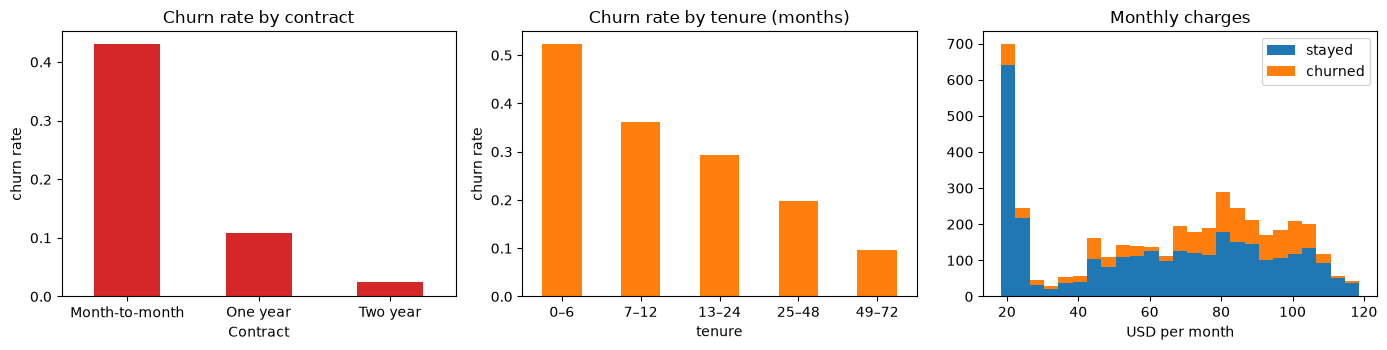

In [9]:
train_df = splits["train"]
churned = train_df["Churn"].eq("Yes")


def churn_by(column):
    return train_df.groupby(column)["Churn"].agg(churn_rate=lambda s: s.eq("Yes").mean(), customers="size").sort_values("churn_rate", ascending=False)


for column in ["Contract", "InternetService", "PaymentMethod"]:
    print(churn_by(column).round(3).to_string(), "\n")

tenure_bucket = pd.cut(train_df["tenure"], bins=[-1, 6, 12, 24, 48, 72], labels=["0–6", "7–12", "13–24", "25–48", "49–72"])
by_tenure = churned.groupby(tenure_bucket, observed=True).mean()
contract = churn_by("Contract")["churn_rate"]
print(f"FINDING 1: month-to-month churn {contract['Month-to-month']:.1%} vs two-year {contract['Two year']:.1%} "
      f"({contract['Month-to-month'] / contract['Two year']:.0f}× higher)")
print(f"FINDING 2: churn in the first 6 months {by_tenure.iloc[0]:.1%} vs after 4 years {by_tenure.iloc[-1]:.1%}")
print(f"FINDING 3: median monthly charge — churners ${train_df.loc[churned, 'MonthlyCharges'].median():.2f} vs "
      f"stayers ${train_df.loc[~churned, 'MonthlyCharges'].median():.2f}")
corr = train_df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()
print(f"FINDING 4: TotalCharges correlates {corr.loc['tenure', 'TotalCharges']:.2f} with tenure (largely redundant information)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
contract.plot.bar(ax=axes[0], color="tab:red", rot=0, title="Churn rate by contract")
by_tenure.plot.bar(ax=axes[1], color="tab:orange", rot=0, title="Churn rate by tenure (months)")
axes[2].hist([train_df.loc[~churned, "MonthlyCharges"], train_df.loc[churned, "MonthlyCharges"]], bins=25, label=["stayed", "churned"], stacked=True)
axes[2].set(title="Monthly charges", xlabel="USD per month")
axes[2].legend()
for ax in axes[:2]:
    ax.set_ylabel("churn rate")
plt.tight_layout()
plt.show()

What these findings change:
- **Contract and tenure dominate.** New, month-to-month customers are the risk group; a linear model with one-hot contract and scaled tenure may already capture most of this.
- **Higher bills churn more**, and they are also worth more to save → the profit metric and the model pull in the same direction.
- **Mild class imbalance** (~26.5% churn): not extreme, so we keep natural class weights and fix decisions with the threshold instead of resampling (resampling distorts probabilities).
- `TotalCharges` ≈ `tenure × MonthlyCharges` — we add a `charges_ratio` feature that captures the part that *isn't* redundant (price changes).

> 💡 **Interview angle:** "Did you do EDA on the whole dataset?" — no, only on training data, so feature ideas couldn't be influenced by test rows. Keep EDA short and decision-driven: each plot should change something in the pipeline.

## Step 5. Features and Preprocessing Pipelines 🟡

Everything that transforms data lives **inside one scikit-learn `Pipeline`**, saved as one file:

```
raw columns ──▶ FeatureAdder ──▶ ColumnTransformer ──▶ model
                (n_services,     linear: impute + scale numbers, one-hot categories
                 charges_ratio)  tree:   ordinal-encode categories, numbers as-is
```

- `FeatureAdder` computes **row-wise** features (no statistics learned from data), so it cannot leak information between rows or splits.
- The scaler and encoders **learn** statistics, so they must be fitted on training folds only — the pipeline guarantees this inside cross-validation.
- At serving time the API passes raw columns and the pipeline does the rest: no duplicated feature code to drift out of sync.

In [10]:
show_source(add_features)
engineered = add_features(X_train)
print(engineered[["tenure", "MonthlyCharges", "TotalCharges", *ENGINEERED_FEATURES]].head(4).to_string())
print("\nchurn rate by number of add-on services (train):")
print(y_train.groupby(engineered["n_services"]).agg(["mean", "size"]).T.round(3).to_string())

models = candidate_models(cfg.SEED)
for name, model in models.items():
    features_out = clone(model[:-1]).fit(X_train, y_train).transform(X_train.head(5))
    print(f"{name:20s} → {model[-1].__class__.__name__:32s} sees {np.asarray(features_out).shape[1]} columns")
models["logistic_regression"]

# churn_service/src/churn_service/features.py
def add_features(X: pd.DataFrame) -> pd.DataFrame:
    """Row-wise features only (no statistics learned from data), so they can never leak across splits."""
    out = X.copy()
    out["n_services"] = X[SERVICE_COLUMNS].eq("Yes").sum(axis=1).astype("int64")
    expected_total = X["tenure"] * X["MonthlyCharges"]
    # > 1: paid more than today's price implies (price went down); < 1: price went up. New customers → 1.0
    out["charges_ratio"] = (X["TotalCharges"] / expected_total.where(expected_total > 0)).fillna(1.0)
    return out
   tenure  MonthlyCharges  TotalCharges  n_services  charges_ratio
0      18           20.10        401.85           1         1.1107
1       7           96.20        639.70           4         0.9500
2      52          109.30       5731.40           7         1.0084
3      46           19.95        927.10           1         1.0102

churn rate by number of add-on services (train):
n_services       0         1     

logistic_regression  → LogisticRegression               sees 47 columns
gradient_boosting    → HistGradientBoostingClassifier   sees 21 columns


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g.

### ✍️ Your Turn

In the training split, which `n_services` value has the **highest churn rate**, considering only values with **at least 100 customers**? Return the integer.

In [11]:
riskiest_n_services = None  # TODO: group y_train by engineered["n_services"], keep groups with size >= 100, take idxmax of the mean
stats = y_train.groupby(engineered["n_services"]).agg(["mean", "size"])
check("riskiest_n_services", riskiest_n_services, int(stats.loc[stats["size"] >= 100, "mean"].idxmax()),
      hint="stats = y_train.groupby(engineered['n_services']).agg(['mean', 'size']); filter rows with size >= 100; idxmax on 'mean'.")

⏳ riskiest_n_services: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
stats = y_train.groupby(engineered["n_services"]).agg(["mean", "size"])
riskiest_n_services = int(stats.loc[stats["size"] >= 100, "mean"].idxmax())
print(riskiest_n_services, stats.loc[riskiest_n_services].round(3).to_dict())
check("riskiest_n_services", riskiest_n_services, int(stats.loc[stats["size"] >= 100, "mean"].idxmax()))
```
</details>

> 💡 **Interview angle:** "How do you prevent training/serving skew?" — put feature engineering and preprocessing inside the saved pipeline (or a shared feature library/feature store), and test that the API's predictions equal the offline pipeline's predictions for the same rows. Our `tests/test_api.py` does exactly that.

## Step 6. Baseline vs Gradient Boosting With Cross-Validation 🟡

Always start with a **strong simple baseline**. Logistic regression is fast, well calibrated by construction, and easy to explain. Gradient boosting (scikit-learn's `HistGradientBoostingClassifier`, the same family as LightGBM) captures interactions and non-linearities.

We compare them with **5-fold stratified cross-validation on the training split** and choose with the **one-standard-error rule**: if the simpler model scores within one standard error of the best, pick the simpler one. A difference of a few thousandths of AUC is noise at this data size and doesn't pay for extra complexity.

In [12]:
start = time.perf_counter()
cv_table = cross_validate_models(models, X_train, y_train, seed=cfg.SEED)
model_type, selection_reason = select_model(cv_table)
print(f"cross-validation took {time.perf_counter() - start:.1f} s")
print(cv_table.drop(columns="n_folds").round(4).to_string())
prior = y_train.mean()
print(f"\nreference: predicting the base rate {prior:.3f} for everyone gives ROC-AUC 0.5 and Brier {prior * (1 - prior):.4f}")
print(f"SELECTED: {selection_reason}")

pipeline = clone(models[model_type]).fit(X_train, y_train)
print(f"fitted {model_type} on all {len(X_train):,} training rows")

cross-validation took 2.2 s
                     roc_auc_mean  roc_auc_std  average_precision_mean  average_precision_std  brier_mean  brier_std  log_loss_mean  log_loss_std  fit_seconds
model                                                                                                                                                         
logistic_regression        0.8480       0.0107                  0.6670                 0.0243      0.1346     0.0039         0.4144        0.0137       0.0175
gradient_boosting          0.8444       0.0104                  0.6602                 0.0149      0.1359     0.0035         0.4185        0.0123       0.3741

reference: predicting the base rate 0.265 for everyone gives ROC-AUC 0.5 and Brier 0.1949
SELECTED: logistic_regression has the best mean CV roc_auc (0.8480)
fitted logistic_regression on all 4,225 training rows


If gradient boosting doesn't clearly win on this data, that's a real and common result: the Telco features are mostly **one-hot categories with near-monotonic effects** (longer contract → less churn), which a linear model represents well, and 4,225 training rows don't leave much room for complex interactions. In an interview, "the simple model won and here's why" is a strong answer.

> 💡 **Interview angle:** "How did you pick the model?" — same CV folds for every candidate, a metric tied to the decision (ranking quality + probability quality), and a tie-break toward simplicity (latency, explainability, maintenance). Never pick on the test set.

## Step 7. Choose the Threshold on Validation to Maximize Profit 🟡

The model outputs probabilities; the business needs yes/no. We score the **validation** split, compute expected profit per 1,000 customers for every threshold from 0.01 to 0.99, and keep the best one. The test set stays locked.

best threshold on validation: 0.23
           profit_per_1000  contact_rate  precision  recall
threshold                                                  
0.23             45284.649         0.441      0.493   0.818
0.50             36542.214         0.216      0.658   0.535

profit per 1,000 customers — threshold 0.23: $45,285 | threshold 0.50: $36,542 | contact everyone: $24,521 | contact nobody: $0


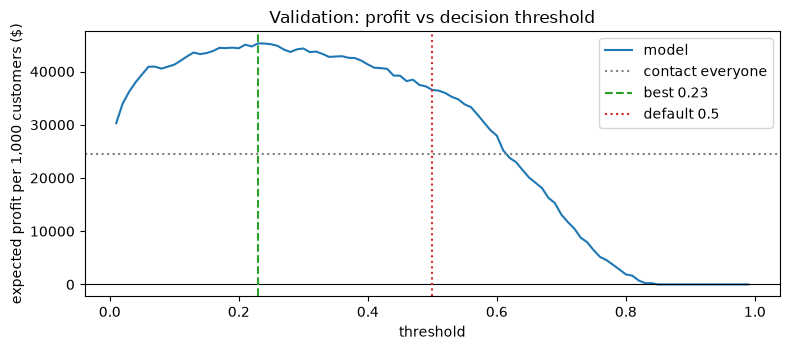

In [13]:
val_proba = pipeline.predict_proba(X_val)[:, 1]
curve = profit_curve(y_val, val_proba, X_val["MonthlyCharges"], assumptions)
threshold = best_threshold(curve)
at = curve.set_index("threshold")
contact_all = profit_per_1000(y_val, np.ones(len(y_val)), X_val["MonthlyCharges"], assumptions)
print(f"best threshold on validation: {threshold:.2f}")
print(at.loc[[threshold, 0.5]].round(3).to_string())
print(f"\nprofit per 1,000 customers — threshold {threshold:.2f}: ${at.loc[threshold, 'profit_per_1000']:,.0f} | "
      f"threshold 0.50: ${at.loc[0.5, 'profit_per_1000']:,.0f} | contact everyone: ${contact_all:,.0f} | contact nobody: $0")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(curve["threshold"], curve["profit_per_1000"], label="model")
ax.axhline(contact_all, color="gray", ls=":", label="contact everyone")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(threshold, color="tab:green", ls="--", label=f"best {threshold:.2f}")
ax.axvline(0.5, color="tab:red", ls=":", label="default 0.5")
ax.set(xlabel="threshold", ylabel="expected profit per 1,000 customers ($)", title="Validation: profit vs decision threshold")
ax.legend()
plt.tight_layout()
plt.show()

**How sensitive is the decision to the assumptions?** If a small change in the offer cost moves the best threshold a lot, the business must pin those numbers down before launch.

In [14]:
rows = []
for offer_cost in [30, 60, 120]:
    for acceptance_rate in [0.2, 0.35, 0.5]:
        scenario = replace(assumptions, offer_cost=offer_cost, acceptance_rate=acceptance_rate)
        scenario_curve = profit_curve(y_val, val_proba, X_val["MonthlyCharges"], scenario)
        best = best_threshold(scenario_curve)
        rows.append({"offer_cost": offer_cost, "acceptance_rate": acceptance_rate, "best_threshold": best,
                     "profit_per_1000": scenario_curve.set_index("threshold").loc[best, "profit_per_1000"],
                     "contact_rate": scenario_curve.set_index("threshold").loc[best, "contact_rate"]})
sensitivity = pd.DataFrame(rows)
print(sensitivity.pivot(index="offer_cost", columns="acceptance_rate", values="best_threshold").to_string())
print(f"\nbest threshold ranges from {sensitivity['best_threshold'].min():.2f} to {sensitivity['best_threshold'].max():.2f} "
      f"across these scenarios → the threshold must be re-tuned whenever the assumptions change")

acceptance_rate  0.20  0.35  0.50
offer_cost                       
30               0.23  0.06  0.06
60               0.38  0.23  0.17
120              0.58  0.43  0.30

best threshold ranges from 0.06 to 0.58 across these scenarios → the threshold must be re-tuned whenever the assumptions change


### ✍️ Your Turn

Compute the validation **profit per 1,000 customers** if we contacted everyone with a churn probability of at least **0.7** (use `profit_per_1000`).

In [15]:
profit_at_070 = None  # TODO: profit_per_1000(y_val, val_proba >= 0.7, X_val["MonthlyCharges"], assumptions)
check("profit_at_070", profit_at_070, at.loc[0.7, "profit_per_1000"], hint="The contact decision is the boolean array val_proba >= 0.7.")

⏳ profit_at_070: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
profit_at_070 = profit_per_1000(y_val, val_proba >= 0.7, X_val["MonthlyCharges"], assumptions)
print(f"${profit_at_070:,.0f} per 1,000 customers — a high threshold contacts few people and misses savable churners")
check("profit_at_070", profit_at_070, at.loc[0.7, "profit_per_1000"])
```
</details>

> 💡 **Interview angle:** "Where did your threshold come from?" — from a cost model on a validation split, with a sensitivity table. scikit-learn's `TunedThresholdClassifierCV` automates the same idea with cross-validation; I used an explicit validation split so the service can store and audit a single number.

## Step 8. Calibration Check 🟡

The break-even formula assumes that a predicted 30% really means 30% of such customers churn. A **reliability table** groups validation customers into 10 equal-size bins by predicted probability and compares the average prediction with the observed churn rate. **Expected calibration error (ECE)** is the size-weighted average gap. We also compare against the other candidate model.

     mean_predicted  observed_rate    n
bin                                    
0             0.005          0.021  141
1             0.017          0.028  141
2             0.042          0.035  141
3             0.087          0.135  141
4             0.153          0.163  141
5             0.224          0.221  140
6             0.324          0.270  141
7             0.450          0.426  141
8             0.588          0.610  141
9             0.720          0.745  141

ECE logistic_regression: 0.022 | ECE gradient_boosting: 0.027 | Brier logistic_regression: 0.1381
→ well calibrated (ECE < 0.05): probabilities can be read as risks
theory: break-even probability at the median bill ($70.40) = 0.20 | tuned threshold = 0.23


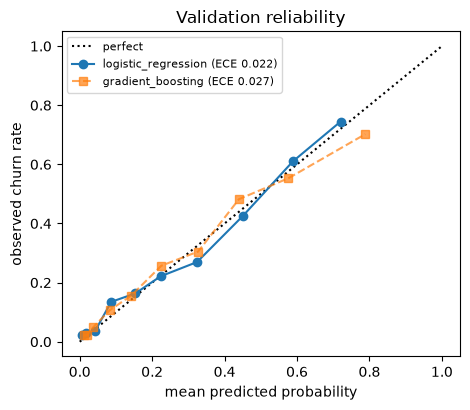

In [16]:
cal_table, ece = calibration_table(y_val, val_proba)
other_type = next(name for name in models if name != model_type)
other_proba = clone(models[other_type]).fit(X_train, y_train).predict_proba(X_val)[:, 1]
_, other_ece = calibration_table(y_val, other_proba)
print(cal_table.round(3).to_string())
print(f"\nECE {model_type}: {ece:.3f} | ECE {other_type}: {other_ece:.3f} | "
      f"Brier {model_type}: {metric_row(y_val, val_proba, X_val['MonthlyCharges'], threshold, assumptions)['brier']:.4f}")
print("→ " + ("well calibrated (ECE < 0.05): probabilities can be read as risks" if ece < 0.05
             else "noticeable miscalibration: consider CalibratedClassifierCV before trusting the break-even formula"))

median_charge = X_train["MonthlyCharges"].median()
print(f"theory: break-even probability at the median bill (${median_charge:.2f}) = {break_even_probability(median_charge, assumptions):.2f} "
      f"| tuned threshold = {threshold:.2f}")

fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.plot([0, 1], [0, 1], "k:", label="perfect")
ax.plot(cal_table["mean_predicted"], cal_table["observed_rate"], "o-", label=f"{model_type} (ECE {ece:.3f})")
other_table, _ = calibration_table(y_val, other_proba)
ax.plot(other_table["mean_predicted"], other_table["observed_rate"], "s--", alpha=0.7, label=f"{other_type} (ECE {other_ece:.3f})")
ax.set(xlabel="mean predicted probability", ylabel="observed churn rate", title="Validation reliability")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The tuned threshold and the theoretical break-even at the median bill should land close together when the model is calibrated — a useful sanity check that the profit code and the probabilities agree. They won't match exactly: the tuned threshold is one number for customers with very different bills.

> 💡 **Interview angle:** "Your model has great AUC — can I use its scores as probabilities?" — AUC only measures ranking. Check calibration (reliability curve, Brier, ECE) on held-out data; fix with Platt/sigmoid or isotonic calibration fitted on data the model wasn't trained on.

## Step 9. Explainability: What Drives the Predictions? 🟡

**Permutation importance** shuffles one raw input column at a time on the validation split and measures how much ROC-AUC drops. It works for any model, and because it shuffles *raw* columns, a one-hot-encoded category counts as one feature. For a logistic regression we can also read the **coefficients** (on standardized numbers and one-hot categories): positive = pushes toward churn.

        feature  importance_mean  importance_std
         tenure           0.2437          0.0100
   TotalCharges           0.0762          0.0046
       Contract           0.0345          0.0055
InternetService           0.0335          0.0046
 MonthlyCharges           0.0245          0.0037
 OnlineSecurity           0.0050          0.0024
  PaymentMethod           0.0049          0.0012
    TechSupport           0.0041          0.0011

strongest churn driver: Contract_Month-to-month (+0.65) | strongest retention driver: tenure (-1.29)


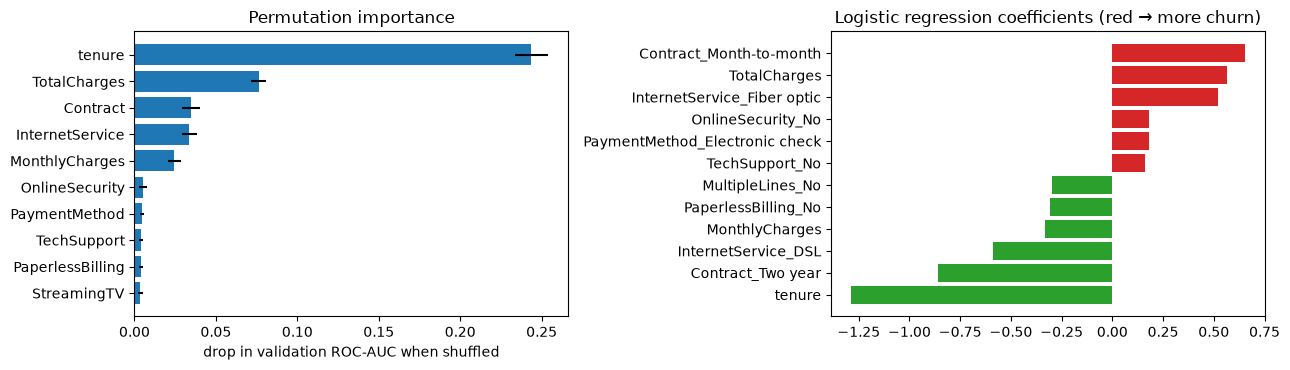

In [17]:
importance = permutation_importance_table(pipeline, X_val, y_val, n_repeats=10, seed=cfg.SEED)
print(importance.head(8).round(4).to_string(index=False))
top = importance.head(10).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="tab:blue")
axes[0].set(xlabel="drop in validation ROC-AUC when shuffled", title="Permutation importance")
if model_type == "logistic_regression":
    names = pipeline[:-1].get_feature_names_out()
    coefs = pd.Series(pipeline[-1].coef_[0], index=names).sort_values()
    shown = pd.concat([coefs.head(6), coefs.tail(6)])
    axes[1].barh(shown.index, shown.values, color=np.where(shown.values > 0, "tab:red", "tab:green"))
    axes[1].set(title="Logistic regression coefficients (red → more churn)")
    print(f"\nstrongest churn driver: {coefs.idxmax()} ({coefs.max():+.2f}) | strongest retention driver: {coefs.idxmin()} ({coefs.min():+.2f})")
else:
    axes[1].axis("off")
    print("⏭️ Coefficients only exist for the linear model; the booster was selected, so see permutation importance.")
plt.tight_layout()
plt.show()

Read importance carefully: it tells you what the **model** relies on, not what **causes** churn. `tenure`, `MonthlyCharges`, and `TotalCharges` are strongly correlated, so shuffling one of them underestimates the group (the others still carry the signal). For per-customer explanations ("why is *this* customer at risk?"), SHAP values are the usual next step.

> 💡 **Interview angle:** "Does 'Fiber optic' cause churn?" — no causal claim from a predictive model. It may proxy price or service quality. To learn what an offer *changes*, you need an experiment (A/B test) or uplift modelling.

## 📏 Evaluation

Model, threshold, and features are now **frozen**. We score the test split exactly **once** and report every number with a **95% bootstrap confidence interval**: resample the 1,409 test customers with replacement 1,000 times, recompute each metric, and take the 2.5th and 97.5th percentiles. That shows how much a number could move with a different sample of customers.

In [18]:
test_proba = pipeline.predict_proba(X_test)[:, 1]          # 🔓 the only time the test split is scored
start = time.perf_counter()
test_metrics = bootstrap_metrics(y_test, test_proba, X_test["MonthlyCharges"], threshold, assumptions, n_boot=1000, seed=cfg.SEED)
print(f"bootstrap took {time.perf_counter() - start:.1f} s")
formatted = test_metrics.copy()
print(formatted.round(4).to_string())

cv_auc = cv_table.loc[model_type, "roc_auc_mean"]
val_auc = metric_row(y_val, val_proba, X_val["MonthlyCharges"], threshold, assumptions)["roc_auc"]
auc = test_metrics.loc["roc_auc"]
print(f"\nROC-AUC — CV {cv_auc:.3f} | validation {val_auc:.3f} | test {auc['estimate']:.3f} (95% CI {auc['ci_low']:.3f}–{auc['ci_high']:.3f})")
print("→ " + ("CV and validation AUC fall inside the test interval: no sign of overfitting to our model-selection data"
             if auc["ci_low"] <= cv_auc <= auc["ci_high"] and auc["ci_low"] <= val_auc <= auc["ci_high"]
             else "CV/validation AUC fall outside the test interval: investigate overfitting or a split issue"))

bootstrap took 1.4 s
                                estimate      ci_low     ci_high
roc_auc                           0.8428      0.8202      0.8636
average_precision                 0.6338      0.5805      0.6856
brier                             0.1378      0.1271      0.1483
log_loss                          0.4198      0.3904      0.4474
precision                         0.4874      0.4477      0.5259
recall                            0.8289      0.7881      0.8652
contact_rate                      0.4514      0.4258      0.4776
profit_per_1000               42034.9823  35369.5742  48325.2312
profit_gain_vs_contact_all    20911.7885  17568.1341  23994.1874
profit_gain_vs_threshold_0.5   7228.4670   3649.2631  11023.6474

ROC-AUC — CV 0.848 | validation 0.836 | test 0.843 (95% CI 0.820–0.864)
→ CV and validation AUC fall inside the test interval: no sign of overfitting to our model-selection data


In [19]:
policies = {f"model, threshold {threshold:.2f}": test_proba >= threshold, "model, threshold 0.50": test_proba >= 0.5,
            "contact everyone": np.ones(len(y_test), bool), "contact nobody": np.zeros(len(y_test), bool)}
policy_table = pd.DataFrame([{
    "policy": name,
    "profit_per_1000": profit_per_1000(y_test, contact, X_test["MonthlyCharges"], assumptions),
    "contact_rate": contact.mean(),
    "precision": (contact & (y_test.to_numpy() == 1)).sum() / max(contact.sum(), 1),
    "recall": (contact & (y_test.to_numpy() == 1)).sum() / (y_test == 1).sum(),
} for name, contact in policies.items()]).set_index("policy")
print(policy_table.round(3).to_string())

gain_all, gain_05 = test_metrics.loc["profit_gain_vs_contact_all"], test_metrics.loc["profit_gain_vs_threshold_0.5"]
for label, gain in [("contacting everyone", gain_all), ("the default 0.5 threshold", gain_05)]:
    verdict = "clearly better (CI excludes $0)" if gain["ci_low"] > 0 else "not clearly different (CI includes $0)"
    print(f"vs {label}: ${gain['estimate']:+,.0f} per 1,000 customers (95% CI ${gain['ci_low']:+,.0f} to ${gain['ci_high']:+,.0f}) → {verdict}")

contact = test_proba >= threshold
confusion = pd.crosstab(pd.Series(np.where(y_test == 1, "churned", "stayed"), name="actual"),
                        pd.Series(np.where(contact, "contact", "no contact"), name="decision"))
print("\n", confusion.to_string())

                       profit_per_1000  contact_rate  precision  recall
policy                                                                 
model, threshold 0.23        42034.982         0.451      0.487   0.829
model, threshold 0.50        34806.515         0.226      0.646   0.551
contact everyone             21123.194         1.000      0.265   1.000
contact nobody                   0.000         0.000      0.000   0.000
vs contacting everyone: $+20,912 per 1,000 customers (95% CI $+17,568 to $+23,994) → clearly better (CI excludes $0)
vs the default 0.5 threshold: $+7,228 per 1,000 customers (95% CI $+3,649 to $+11,024) → clearly better (CI excludes $0)

 decision  contact  no contact
actual                       
churned       310          64
stayed        326         709


**Slices.** An average can hide groups where the model is much worse. We check gender, senior citizens, and contract type on the test split (evaluation only, nothing is tuned on these numbers).

In [20]:
test_slices = evaluation_slices(y_test, test_proba, threshold, X_test)
slice_table = pd.DataFrame(test_slices).set_index("slice")
print(slice_table.round(3).to_string())
auc_range = slice_table["roc_auc"].max() - slice_table["roc_auc"].min()
print(f"\nROC-AUC ranges {slice_table['roc_auc'].min():.3f}–{slice_table['roc_auc'].max():.3f} across slices. "
      "Within a single contract type the model can only rank on the remaining features, so lower within-slice AUC is expected. "
      "Recall differences matter more for fairness: who gets offers.")

                              n  churn_rate  roc_auc  recall
slice                                                       
gender = Female             687       0.281    0.840   0.819
gender = Male               722       0.251    0.846   0.840
senior citizen = 0         1187       0.233    0.843   0.786
senior citizen = 1          222       0.441    0.784   0.949
contract = Month-to-month   773       0.426    0.745   0.909
contract = One year         300       0.120    0.739   0.306
contract = Two year         336       0.027    0.756   0.000

ROC-AUC ranges 0.739–0.846 across slices. Within a single contract type the model can only rank on the remaining features, so lower within-slice AUC is expected. Recall differences matter more for fairness: who gets offers.


> 💡 **Interview angle:** "How confident are you in that test score?" — give the interval, not just the point estimate. With 1,409 customers, ROC-AUC moves by a few hundredths across resamples, and profit differences between policies can be much less certain than they look.

## 🚢 Deployment

The model is good enough against our success criteria, so we ship it. The project folder [`churn_service/`](churn_service/README.md) contains everything below; each subsection runs the real thing.

### 1. Save the model with metadata and a model card

A pickle alone is not a deployable model. We save **metadata** next to it: version, training-data hashes, library versions, assumptions, threshold, and all metrics. The API reads its threshold from this file (never from code), and the version appears in every response. We also save **reference statistics** of the training data for drift monitoring, and generate a **model card** from the metadata.

In [21]:
metadata = build_metadata(model_type=model_type, pipeline=pipeline, threshold=threshold, assumptions=assumptions,
                          raw_sha256=file_sha256(raw_path), split_hashes=split_hashes, splits=splits, cv_table=cv_table,
                          selection_reason=selection_reason, validation_metrics=metric_row(y_val, val_proba, X_val["MonthlyCharges"], threshold, assumptions),
                          test_metrics=test_metrics, test_slices=test_slices)
reference = reference_statistics(X_train, pipeline.predict_proba(X_train)[:, 1])
paths = save_artifacts(pipeline, metadata, reference, cfg.artifacts_dir())
for path in paths.values():
    print(f"{rel(path):55s} {path.stat().st_size / 1024:7.1f} KB")
print(json.dumps({k: metadata[k] for k in ["model_version", "model_type", "threshold", "sklearn_version", "business_assumptions"]}, indent=2))

loaded = ChurnModel.load(cfg.artifacts_dir())
assert np.allclose(loaded.predict_proba(X_test), test_proba) and loaded.threshold == threshold
print(f"✅ reloaded model {loaded.version} reproduces all {len(X_test):,} test probabilities")
display(Markdown(paths["MODEL_CARD.md"].read_text()))

churn_service/artifacts/model.joblib                        8.5 KB
churn_service/artifacts/metadata.json                       5.9 KB
churn_service/artifacts/reference_stats.json                4.0 KB
churn_service/artifacts/MODEL_CARD.md                       2.4 KB
{
  "model_version": "1.0.0+3aa08e0a",
  "model_type": "logistic_regression",
  "threshold": 0.23,
  "sklearn_version": "1.9.1",
  "business_assumptions": {
    "offer_cost": 60.0,
    "acceptance_rate": 0.35,
    "months_retained": 12
  }
}
✅ reloaded model 1.0.0+3aa08e0a reproduces all 1,409 test probabilities


# Model Card — churn-classifier 1.0.0+3aa08e0a

## Model details
- **Type:** LogisticRegression inside a scikit-learn pipeline (feature engineering + preprocessing + model)
- **Trained:** 2026-09-14T02:45:49+00:00 with scikit-learn 1.9.1, pandas 3.0.5
- **Selection:** logistic_regression has the best mean CV roc_auc (0.8480)
- **Decision threshold:** contact a customer when P(churn) ≥ **0.23** (maximizes expected profit on the validation split)

## Intended use
Rank existing telecom customers by churn risk so a retention team can decide who receives a retention offer.
**Not** for pricing, credit, or any decision that denies service. A human team owns the final contact decision.

## Data
IBM Telco Customer Churn sample (https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv), Apache-2.0. One snapshot of 7,043 fictional customers of one company.
Stratified splits — train 4,225 / validation 1,409 / test 1,409 rows
(train SHA-256 `839ca46c82e63a48…`).

## Business assumptions (not from the data — replace with real numbers)
offer cost $60 per contacted customer · 35% of contacted churners stay · 12 months of revenue kept

## Test-set results (used once)
- ROC-AUC 0.843 (95% CI 0.820–0.864) · average precision 0.634 (95% CI 0.581–0.686) · Brier 0.138 (95% CI 0.127–0.148)
- At the threshold: precision 0.487 (95% CI 0.448–0.526), recall 0.829 (95% CI 0.788–0.865), contacting 45.1% of customers
- Expected profit per 1,000 customers: $42,035 (95% CI $35,370–$48,325)
- Gain vs contacting everyone: $20,912 (95% CI $17,568–$23,994) · vs threshold 0.5: $7,228 (95% CI $3,649–$11,024)

| slice | n | churn rate | ROC-AUC | recall |
|---|---|---|---|---|
| gender = Female | 687 | 28.1% | 0.840 | 81.9% |
| gender = Male | 722 | 25.1% | 0.846 | 84.0% |
| senior citizen = 0 | 1187 | 23.3% | 0.843 | 78.6% |
| senior citizen = 1 | 222 | 44.1% | 0.784 | 94.9% |
| contract = Month-to-month | 773 | 42.6% | 0.745 | 90.9% |
| contract = One year | 300 | 12.0% | 0.739 | 30.6% |
| contract = Two year | 336 | 2.7% | 0.756 | 0.0% |

## Limitations and risks
- Profit numbers are only as good as the assumptions above; the threshold must be re-tuned when they change.
- Single, old, fictional snapshot: no seasonality, no time-based validation, no causal effect of offers (uplift) measured.
- Probabilities are from one company's customers; re-validate before using elsewhere. Monitor drift with `reference_stats.json`.


### 2. Reproduce the whole pipeline with one command

The notebook called the package step by step. The same steps run as a CLI (`python -m churn_service.train`), which is what CI uses. Running it from scratch in a separate folder must give the **same model version, threshold, and test AUC** (fewer bootstrap resamples to save time; only the CI bounds depend on that).

In [22]:
cli_data, cli_artifacts = OUTPUT_DIR / "cli_data", OUTPUT_DIR / "cli_artifacts"
shutil.rmtree(cli_data, ignore_errors=True)
shutil.rmtree(cli_artifacts, ignore_errors=True)
cli = run([sys.executable, "-m", "churn_service.train", "--data-dir", cli_data, "--artifacts-dir", cli_artifacts, "--n-boot", "200"],
          env={"PYTHONPATH": str(PROJECT_DIR / "src")})
assert cli.returncode == 0
cli_meta = json.loads((cli_artifacts / "metadata.json").read_text())
same = {key: cli_meta[key] == metadata[key] for key in ["model_version", "threshold", "model_type"]}
same["test roc_auc"] = math.isclose(cli_meta["test_metrics"]["roc_auc"]["estimate"], metadata["test_metrics"]["roc_auc"]["estimate"])
same["train split sha256"] = cli_meta["data"]["splits"]["train"]["sha256"] == metadata["data"]["splits"]["train"]["sha256"]
print(same)
assert all(same.values())
print("✅ the CLI reproduces the notebook's model from a fresh download")

$ python -m churn_service.train --data-dir _outputs/churn/cli_data --artifacts-dir _outputs/churn/cli_artifacts --n-boot 200


  ✅ passed: 7,043 rows, 0 errors, 1 warnings
    WARNING TotalCharges: 11 blank values, all with tenure == 0 (not billed yet) → cleaned to 0.0
  model selection: logistic_regression has the best mean CV roc_auc (0.8480)
  threshold chosen on validation: 0.23
  saved model 1.0.0+3aa08e0a | test ROC-AUC 0.843 | 3.8 s
  [exit code 0 · 4.8 s]
{'model_version': True, 'threshold': True, 'model_type': True, 'test roc_auc': True, 'train split sha256': True}
✅ the CLI reproduces the notebook's model from a fresh download


### 3. The API contract and the FastAPI service

`schemas.py` defines the request with **Pydantic v2**: exact allowed categories (`Literal[...]`), numeric ranges, `extra="forbid"` for unknown fields, and a `model_validator` for cross-field rules (e.g. no streaming TV without internet). Invalid requests never reach the model; FastAPI answers **422** with a precise error.

`api.py` highlights:
- **Lifespan** loads the model once at startup. If artifacts are missing the process stays up: `/health` (liveness) says 200, `/ready` (readiness) says 503, so a load balancer won't send traffic to it.
- **Plain `def` endpoints**: scikit-learn is CPU-bound, so FastAPI runs them in a thread pool instead of blocking the event loop.
- `/predict` for one customer, `/predict/batch` for up to 1,000 in a single vectorized call. Every response includes `threshold` and `model_version`.

In [23]:
from fastapi.testclient import TestClient  # noqa: E402

from churn_service.api import create_app  # noqa: E402

show_source(create_app, max_lines=70)

# churn_service/src/churn_service/api.py
def create_app(artifacts_dir: str | Path | None = None) -> FastAPI:
    """App factory: tests pass their own artifacts folder; production reads CHURN_ARTIFACTS_DIR at startup."""

    @asynccontextmanager
    async def lifespan(app: FastAPI):
        directory = Path(artifacts_dir) if artifacts_dir is not None else cfg.artifacts_dir()
        app.state.model, app.state.load_error = None, None
        try:
            app.state.model = ChurnModel.load(directory)  # once per process, not once per request
            logger.info("loaded model %s (threshold %.2f)", app.state.model.version, app.state.model.threshold)
        except (FileNotFoundError, ValueError, KeyError) as err:
            app.state.load_error = str(err)  # stay alive so /health works, but /ready reports 503
            logger.error("model not loaded: %s", err)
        yield
        app.state.model = None

    app = FastAPI(title="Churn Prediction Service", version=__version__, li

In [24]:
with TestClient(create_app(cfg.artifacts_dir())) as client:
    print("GET /ready →", client.get("/ready").json())
    response = client.post("/predict", json=EXAMPLE_CUSTOMER)
    print("POST /predict →", response.status_code, response.json())
    bad = client.post("/predict", json={**EXAMPLE_CUSTOMER, "contract": "Monthly", "tenure": -1, "internet_service": "No"})
    print("POST /predict (bad input) →", bad.status_code)
    for error in bad.json()["detail"]:
        print("   ", error["loc"], "—", error["msg"])

GET /ready → {'status': 'ready', 'model_version': '1.0.0+3aa08e0a'}
POST /predict → 200 {'customer_id': '7590-VHVEG', 'churn_probability': 0.6193024306515036, 'contact': True, 'threshold': 0.23, 'model_version': '1.0.0+3aa08e0a'}
POST /predict (bad input) → 422
    ['body', 'tenure'] — Input should be greater than or equal to 0
    ['body', 'contract'] — Input should be 'Month-to-month', 'One year' or 'Two year'


The bad request reports the unknown contract and the negative tenure together. The cross-field rule (add-ons without internet) runs only after the individual fields are valid, so it appears once those are fixed.

### 4. Run the test suite

`tests/` has three layers:
- **Unit tests** (`test_data.py`, `test_features_business_monitoring.py`): validation rules, blank `TotalCharges`, disjoint stratified splits, feature values, hand-computed profit, PSI behaviour — tiny hand-made data, no network.
- **API tests** (`test_api.py`): health/readiness, saved threshold and version in responses, batch = single predictions, API = offline pipeline, six kinds of invalid input → 422, service without a model → 503.
- **Model-quality gate** (`test_model_quality.py`): test ROC-AUC must be ≥ **0.80**, the threshold policy must beat *contact everyone* and *contact nobody*, and the test file's hash must match the metadata.

In [25]:
tests = run([sys.executable, "-m", "pytest", "-q", "-rA", "-p", "no:cacheprovider"], max_lines=40)   # -rA lists every passed test
assert tests.returncode == 0, "tests failed"
n_tests_passed = int(re.search(r"(\d+) passed", tests.stdout).group(1))
print(f"✅ {n_tests_passed} tests passed")

$ python -m pytest -q -rA -p no:cacheprovider


  ...........................                                              [100%]
  ==================================== PASSES ====================================
  ____________ test_service_without_artifacts_is_alive_but_not_ready _____________
  ------------------------------ Captured log call -------------------------------
  ERROR    uvicorn.error:api.py:43 model not loaded: model.joblib not found in the artifacts directory — run `python -m churn_service.train` first
  =========================== short test summary info ============================
  PASSED tests/test_api.py::test_health_and_ready
  PASSED tests/test_api.py::test_single_prediction_uses_saved_threshold_and_version
  PASSED tests/test_api.py::test_batch_matches_single_predictions_in_order
  PASSED tests/test_api.py::test_invalid_customers_are_rejected_with_422[change0]
  PASSED tests/test_api.py::test_invalid_customers_are_rejected_with_422[change1]
  PASSED tests/test_api.py::test_invalid_customers_are_rejected_wi

### 5. A real server and real HTTP

`TestClient` calls the app in-process. Now we start **uvicorn** in a background process, send real HTTP requests (one customer at a time and a batch of 200 test customers), measure latency, and stop the server gracefully.

In [26]:
FIELD_FOR_COLUMN = {column: field for field, column in COLUMN_NAMES.items()}


def to_api_json(row, customer_id):
    body = {FIELD_FOR_COLUMN[c]: (row[c].item() if hasattr(row[c], "item") else row[c]) for c in FEATURE_COLUMNS}
    return {"customer_id": customer_id, **body}


test_customers = [to_api_json(row, cid) for (_, row), cid in zip(X_test.head(200).iterrows(), splits["test"]["customerID"].head(200))]

with UvicornServer("churn_service.api:app", cwd=PROJECT_DIR, env={"PYTHONPATH": str(PROJECT_DIR / "src")}) as server:
    print(f"server ready in {server.startup_seconds:.1f} s at {server.base_url}")
    print("GET /model →", httpx.get(f"{server.base_url}/model").json())
    latencies = []
    with httpx.Client(base_url=server.base_url) as http:
        http.post("/predict", json=test_customers[0])                       # warm-up
        for body in test_customers[:50]:
            t0 = time.perf_counter()
            single = http.post("/predict", json=body)
            latencies.append((time.perf_counter() - t0) * 1000)
            assert single.status_code == 200
        t0 = time.perf_counter()
        batch = http.post("/predict/batch", json={"customers": test_customers}).json()
        batch_ms = (time.perf_counter() - t0) * 1000

print(f"single requests: p50 {np.percentile(latencies, 50):.1f} ms, p95 {np.percentile(latencies, 95):.1f} ms | "
      f"batch of {batch['n_customers']}: {batch_ms:.0f} ms ({batch_ms / batch['n_customers']:.2f} ms per customer), {batch['n_contact']} to contact")
served = np.array([p["churn_probability"] for p in batch["predictions"]])
assert np.allclose(served, test_proba[:200]) and batch["threshold"] == threshold
print("✅ HTTP predictions equal the notebook's test probabilities; threshold comes from metadata")
print("--- server log (last lines) ---")
print("\n".join(server.log_text().splitlines()[-6:]))

server ready in 1.2 s at http://127.0.0.1:60347
GET /model → {'model_version': '1.0.0+3aa08e0a', 'model_type': 'logistic_regression', 'trained_at': '2026-09-14T02:45:49+00:00', 'threshold': 0.23, 'business_assumptions': {'offer_cost': 60.0, 'acceptance_rate': 0.35, 'months_retained': 12}, 'test_metrics': {'roc_auc': {'estimate': 0.8427704151489318, 'ci_low': 0.8201826768336258, 'ci_high': 0.8635870689039205}, 'profit_per_1000': {'estimate': 42034.9822569198, 'ci_low': 35369.57416607523, 'ci_high': 48325.23119233498}}}


single requests: p50 5.1 ms, p95 5.8 ms | batch of 200: 7 ms (0.03 ms per customer), 93 to contact
✅ HTTP predictions equal the notebook's test probabilities; threshold comes from metadata
--- server log (last lines) ---
INFO:     127.0.0.1:60361 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:60361 - "POST /predict/batch HTTP/1.1" 200 OK
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [90549]


### 6. Build and run the Docker image

The [`Dockerfile`](churn_service/Dockerfile) is **multi-stage**: a *builder* stage installs the locked dependencies (`requirements.lock`) and the package with `uv`; the *runtime* stage copies only the virtual environment and the three model files. It runs as a **non-root** user and has a **HEALTHCHECK** that calls `/ready`. `.dockerignore` keeps data, tests, and caches out of the build context.

The model files are **baked into the image**, so the image tag identifies code *and* model together (immutable, easy rollback). The alternative, mounting or downloading the model at startup, gives smaller images and independent model releases.

In [27]:
print((PROJECT_DIR / "Dockerfile").read_text())


def docker_status():
    if DOCKER is None:
        return False, "the docker command is not installed"
    try:
        probe = subprocess.run([DOCKER, "info", "--format", "{{.ServerVersion}}"], capture_output=True, text=True, timeout=60)
    except subprocess.TimeoutExpired:
        return False, "the Docker daemon did not answer within 60 s"
    if probe.returncode == 0 and probe.stdout.strip():
        return True, probe.stdout.strip()
    # don't echo docker's error text: it can contain local socket paths with your username
    return False, "the Docker daemon is not reachable (`docker info` failed): start Docker Desktop or the Docker service"


DOCKER_OK, DOCKER_INFO = docker_status()
IMAGE = f"churn-service:{metadata['model_version'].replace('+', '-')}"          # '+' is not allowed in image tags
print(f"Docker available: {DOCKER_OK} ({DOCKER_INFO})")

# syntax=docker/dockerfile:1
# Train first (artifacts/ must exist), then:
#   docker build -t churn-service:1.0.0 .
#   docker run --rm -p 8000:8000 churn-service:1.0.0

# ---------- stage 1: builder — uv, caches and build tools stay here ----------
FROM python:3.12-slim AS builder
COPY --from=ghcr.io/astral-sh/uv:0.10.3 /uv /bin/uv
ENV UV_COMPILE_BYTECODE=1 UV_LINK_MODE=copy UV_PYTHON_DOWNLOADS=never
WORKDIR /build
# Dependencies first: this layer is reused until requirements.lock changes
COPY requirements.lock ./
RUN --mount=type=cache,target=/root/.cache/uv \
    uv venv /opt/venv && \
    uv pip install --python /opt/venv/bin/python -r requirements.lock
# Then the package itself (changes more often)
COPY pyproject.toml README.md ./
COPY src/ ./src/
RUN --mount=type=cache,target=/root/.cache/uv \
    uv pip install --python /opt/venv/bin/python --no-deps .

# ---------- stage 2: runtime — Python, the venv, and the model artifacts only ----------
FROM python:3.12-slim AS runtime
ENV 

Docker available: False (the Docker daemon is not reachable (`docker info` failed): start Docker Desktop or the Docker service)


In [28]:
if not DOCKER_OK:
    print(f"⏭️ Skipped: building the image needs a running Docker daemon ({DOCKER_INFO}). From the churn_service/ folder run:\n"
          f"   docker build -t {IMAGE} .\n   docker run --rm -p 8000:8000 {IMAGE}\n   curl -s localhost:8000/ready")
else:
    build = run([DOCKER, "build", "--progress=plain", "-t", IMAGE, "."], max_lines=8)
    assert build.returncode == 0, "docker build failed"
    size_on_disk = subprocess.run([DOCKER, "image", "ls", IMAGE, "--format", "{{.Size}}"], capture_output=True, text=True).stdout.strip()
    compressed = int(subprocess.run([DOCKER, "image", "inspect", IMAGE, "--format", "{{.Size}}"], capture_output=True, text=True).stdout)
    print(f"\n{IMAGE}: {size_on_disk} on disk, {compressed / 1e6:.0f} MB compressed (what a server pulls)")

    name, port = f"churn-nb-{free_port()}", free_port()
    started = run([DOCKER, "run", "-d", "--name", name, "-p", f"127.0.0.1:{port}:8000", IMAGE], max_lines=1)
    try:
        t0 = time.perf_counter()
        while time.perf_counter() - t0 < 60:
            try:
                if httpx.get(f"http://127.0.0.1:{port}/ready", timeout=1).status_code == 200:
                    break
            except httpx.TransportError:
                time.sleep(0.3)
        print(f"container ready after {time.perf_counter() - t0:.1f} s")
        print("POST /predict →", httpx.post(f"http://127.0.0.1:{port}/predict", json=EXAMPLE_CUSTOMER).json())
        health = "starting"
        while health == "starting" and time.perf_counter() - t0 < 60:
            health = subprocess.run([DOCKER, "inspect", "-f", "{{.State.Health.Status}}", name], capture_output=True, text=True).stdout.strip()
            time.sleep(1)
        user = subprocess.run([DOCKER, "exec", name, "id", "-u"], capture_output=True, text=True).stdout.strip()
        print(f"Docker HEALTHCHECK status: {health} | process user id inside the container: {user} (0 would be root)")
    finally:
        subprocess.run([DOCKER, "rm", "-f", name], capture_output=True)
        print(f"removed container {name}")

⏭️ Skipped: building the image needs a running Docker daemon (the Docker daemon is not reachable (`docker info` failed): start Docker Desktop or the Docker service). From the churn_service/ folder run:
   docker build -t churn-service:1.0.0-3aa08e0a .
   docker run --rm -p 8000:8000 churn-service:1.0.0-3aa08e0a
   curl -s localhost:8000/ready


### 7. CI: lint → train + test → build + smoke test

[`ci/github-actions.yml`](churn_service/ci/github-actions.yml) is an example GitHub Actions workflow (copy it to `.github/workflows/` in your own repository). Three jobs run in order, and each one only runs if the previous one passed:

1. **lint** — `ruff check`.
2. **test** — install locked dependencies, **train** (the dataset is 1 MB and training takes seconds), run **pytest including the model-quality gate**, upload the artifacts.
3. **build** — download the artifacts, `docker build`, start the container, call `/ready` and `/predict` (a *smoke test*).

Retraining happens in CI, so a code change that silently makes the model worse fails the pipeline instead of reaching production. We parse the YAML to check its structure and run the same lint command locally.

In [29]:
workflow = yaml.safe_load((PROJECT_DIR / "ci" / "github-actions.yml").read_text())
triggers = workflow.get("on", workflow.get(True))                 # YAML 1.1 reads a bare `on:` key as True
print("triggers:", list(triggers))
for job_name, job in workflow["jobs"].items():
    steps = [step.get("name") or step.get("uses") for step in job["steps"]]
    print(f"job {job_name:5s} needs={job.get('needs', '-'):5s} → {steps}")
assert workflow["jobs"]["build"]["needs"] == "test" and workflow["jobs"]["test"]["needs"] == "lint"

if UV:
    lint = run([UV, "tool", "run", "ruff@0.16.7", "check", "."], env={"NO_COLOR": "1"}, max_lines=10)
else:
    print("⏭️ Skipped lint: needs uv (https://docs.astral.sh/uv/). Alternative: pip install ruff==0.16.7 && ruff check .")

triggers: ['push', 'pull_request']
job lint  needs=-     → ['actions/checkout@v7', 'astral-sh/setup-uv@v10.1.0', 'Ruff lint']
job test  needs=lint  → ['actions/checkout@v7', 'astral-sh/setup-uv@v10.1.0', 'Install locked runtime dependencies + dev tools', 'Train (downloads the 1 MB dataset, verifies its checksum, < 1 minute)', 'Tests (unit + API + model-quality gate)', 'Keep the trained artifacts for the build job']
job build needs=test  → ['actions/checkout@v7', 'actions/download-artifact@v8', 'Build image', 'Smoke test the container']
$ uv tool run ruff@0.16.7 check .


  All checks passed!
  [exit code 0 · 0.2 s]


### 8. Monitoring plan

Churn labels arrive about **a month after** a prediction, so we can't watch accuracy in real time. The plan combines fast proxy signals with slower ground truth:

| What | How | Alert when | Action |
|---|---|---|---|
| Service health | request rate, error rate (4xx/5xx), p95 latency | 5xx > 1% or p95 > 200 ms | page on-call, roll back image |
| Input data quality | same validation rules as training, on request logs | invalid share jumps | fix upstream data |
| **Input drift** | PSI per feature vs `reference_stats.json` | PSI > 0.25 | investigate, consider retraining |
| **Score drift** | PSI of predicted probabilities, contact rate | PSI > 0.25 or contact rate ±50% | check inputs, re-check threshold |
| Outcomes (monthly) | ROC-AUC, recall at threshold, realized campaign profit | AUC < 0.80 or profit below plan | retrain / re-tune threshold |
| Assumptions | finance updates offer cost / acceptance | any change | re-run threshold tuning |

**PSI** (population stability index) compares two distributions over the same bins: $\text{PSI} = \sum_b (a_b - e_b)\ln(a_b / e_b)$, where $e_b$ and $a_b$ are the reference and current shares in bin $b$. Rules of thumb: < 0.1 stable, 0.1–0.25 watch, > 0.25 investigate.

Below, the unseen test customers should look **stable**. Then we build a **deliberately shifted** copy of them — as if a marketing push brought in many new month-to-month customers and prices rose 15% — to see the report react.

In [30]:
stable = drift_report(reference, X_test, test_proba)
print(f"test split vs training reference: max PSI {stable['psi'].max():.3f} → statuses {stable['status'].value_counts().to_dict()}")

shifted = X_test[(X_test["Contract"] == "Month-to-month") & (X_test["tenure"] <= 12)].copy()
shifted["MonthlyCharges"] = (shifted["MonthlyCharges"] * 1.15).clip(upper=500)
shifted_report = drift_report(reference, shifted, pipeline.predict_proba(shifted)[:, 1])
print(f"\nshifted scenario ({len(shifted)} customers):")
print(shifted_report.head(8).round(3).to_string(index=False))
flagged = shifted_report.loc[shifted_report["status"] == "drift", "feature"].tolist()
print(f"\n→ drift flagged for: {flagged}")

test split vs training reference: max PSI 0.015 → statuses {'ok': 20}

shifted scenario (400 customers):
         feature         kind   psi status
          tenure      numeric 5.544  drift
    TotalCharges      numeric 4.139  drift
        Contract  categorical 3.737  drift
prediction_score model output 2.567  drift
  MonthlyCharges      numeric 0.939  drift
    OnlineBackup  categorical 0.304  drift
         Partner  categorical 0.299  drift
DeviceProtection  categorical 0.262  drift

→ drift flagged for: ['tenure', 'TotalCharges', 'Contract', 'prediction_score', 'MonthlyCharges', 'OnlineBackup', 'Partner', 'DeviceProtection', 'PaymentMethod', 'OnlineSecurity']


### ✍️ Your Turn

From `shifted_report`, get the **PSI of the `Contract` feature** as a float.

In [31]:
contract_psi = None  # TODO: select the row where feature == "Contract" and read the psi column
check("contract_psi", contract_psi, float(shifted_report.set_index("feature").loc["Contract", "psi"]),
      hint="shifted_report.set_index('feature').loc['Contract', 'psi']")

⏳ contract_psi: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
contract_psi = float(shifted_report.set_index("feature").loc["Contract", "psi"])
print(f"Contract PSI = {contract_psi:.2f} — every customer in the shifted group is month-to-month")
check("contract_psi", contract_psi, float(shifted_report.set_index("feature").loc["Contract", "psi"]))
```
</details>

**Stretch goals** (good commits for your GitHub version):
1. Rank customers by **expected value** (`p × acceptance × MonthlyCharges × months − offer_cost`) instead of one global threshold, and compare profit on validation.
2. Add SHAP explanations to the `/predict` response (top 3 reasons per customer).
3. Log every request to a file and run `drift_report` on the log as a scheduled job (see the [Model Monitoring and Drift](../09_MLOps/05_Model_Monitoring_and_Drift.ipynb) notebook).
4. Replace the fixed acceptance rate with an **uplift model** trained on an A/B test of the offer.

## 🗣️ Interview Walkthrough

The pitch below is generated from the saved metadata, so every number in it is real. Practise saying it out loud in about **2 minutes**: problem → approach → result → engineering → what you'd do next.

In [32]:
tm = metadata["test_metrics"]
a = metadata["business_assumptions"]
pitch = f"""
PROBLEM (20 s)
  A telecom company wants to cut churn with retention offers, but each offer costs ${a['offer_cost']:.0f}. I framed it as:
  which customers should we contact to maximize expected profit? Assumptions: {a['acceptance_rate']:.0%} of contacted
  churners stay, and a saved customer is worth {a['months_retained']} months of their bill.

DATA + APPROACH (40 s)
  IBM Telco data, {len(clean_df):,} customers, {clean_df['Churn'].eq('Yes').mean():.1%} churn. Schema and business-rule validation first
  (found and handled {int(parse_total_charges(raw['TotalCharges']).isna().sum())} blank TotalCharges for brand-new customers). A stratified 60/20/20 split,
  EDA on train only. I compared logistic regression and gradient boosting with 5-fold CV: {metadata['selection_reason']}.
  I chose the decision threshold on the validation split by maximizing expected profit: {metadata['threshold']:.2f} instead of 0.5.

RESULT (30 s)
  On the untouched test set: ROC-AUC {tm['roc_auc']['estimate']:.3f} (95% CI {tm['roc_auc']['ci_low']:.3f}–{tm['roc_auc']['ci_high']:.3f}),
  recall {tm['recall']['estimate']:.0%} while contacting {tm['contact_rate']['estimate']:.0%} of customers, expected profit
  ${tm['profit_per_1000']['estimate']:,.0f} per 1,000 customers, ${tm['profit_gain_vs_contact_all']['estimate']:,.0f} more than contacting everyone
  (CI ${tm['profit_gain_vs_contact_all']['ci_low']:,.0f} to ${tm['profit_gain_vs_contact_all']['ci_high']:,.0f}).

ENGINEERING (20 s)
  A Python package with a CLI that reproduces the model from scratch, a FastAPI service with Pydantic validation, batch
  endpoint, readiness checks and the threshold read from versioned metadata ({metadata['model_version']}); {n_tests_passed} pytest tests
  including a model-quality gate; a multi-stage non-root Docker image; and a CI pipeline that retrains, tests, and smoke-tests the container.

NEXT (10 s)
  PSI drift monitoring is wired to saved reference statistics. Next I'd run an A/B test of the offer and move to uplift modelling,
  because a churn model finds who is at risk, not who can be persuaded.
"""
print(pitch)
print(f"({len(pitch.split())} words ≈ {len(pitch.split()) / 150:.1f} minutes at 150 words per minute)")


PROBLEM (20 s)
  A telecom company wants to cut churn with retention offers, but each offer costs $60. I framed it as:
  which customers should we contact to maximize expected profit? Assumptions: 35% of contacted
  churners stay, and a saved customer is worth 12 months of their bill.

DATA + APPROACH (40 s)
  IBM Telco data, 7,043 customers, 26.5% churn. Schema and business-rule validation first
  (found and handled 11 blank TotalCharges for brand-new customers). A stratified 60/20/20 split,
  EDA on train only. I compared logistic regression and gradient boosting with 5-fold CV: logistic_regression has the best mean CV roc_auc (0.8480).
  I chose the decision threshold on the validation split by maximizing expected profit: 0.23 instead of 0.5.

RESULT (30 s)
  On the untouched test set: ROC-AUC 0.843 (95% CI 0.820–0.864),
  recall 83% while contacting 45% of customers, expected profit
  $42,035 per 1,000 customers, $20,912 more than contacting everyone
  (CI $17,568 to $23,994).

EN

**Likely follow-up questions** (answer each in under a minute):

1. *"Where do the $60 and 35% come from?"* — They're explicit assumptions from the business, kept in one config object; I showed a sensitivity table, and the threshold is re-tuned when they change.
2. *"Why did the simpler model win?"* — Same CV folds, one-standard-error rule; the signal is mostly monotonic effects of contract, tenure, and price that a linear model captures, and it's faster and easier to explain.
3. *"How do you know you didn't overfit the threshold?"* — It was chosen on validation, and the test profit (with CI) was computed once afterwards; CV, validation, and test AUC agree.
4. *"What happens when the model is wrong in production?"* — Readiness gate, versioned responses for traceability, rollback to the previous image tag, drift + outcome monitoring, and a CI quality gate for retrains.
5. *"How would this scale to 10 million customers?"* — Monthly batch scoring (Spark or chunked pandas) writing to a table for the CRM; the online API stays for real-time use cases like a call-centre screen.
6. *"Is it fair?"* — Sensitive attributes are inputs here, so I checked recall and contact rate per slice; next step is deciding with stakeholders whether to drop them and re-measuring proxies.

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why choose a decision threshold by expected profit instead of using 0.5 or maximizing F1?**

<details><summary>Show answer</summary>

- **30-second answer:** 0.5 and F1 assume both error types cost about the same. In churn, a missed churner loses months of revenue while an unnecessary offer costs a fixed amount, so I converted the confusion matrix to dollars and picked the threshold that maximizes expected profit on validation data.
- **Go deeper:** With calibrated probabilities the break-even point is `cost / (acceptance × value)`, which gives a theoretical check. Per-customer value means a single threshold is an approximation; ranking by expected value is the next step. `TunedThresholdClassifierCV` in scikit-learn tunes a threshold with CV for any scorer.
- **❌ Common wrong answer:** "Lower the threshold until recall is high" — recall alone ignores the cost of offers to customers who would have stayed.

</details>

**Q2. What is data leakage? Name the leakage risks in this project and how you prevented them.**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage is information from evaluation data (or the future) influencing training, which inflates scores. Here: preprocessing statistics, EDA-driven feature ideas, model selection, and threshold choice. I split first, did EDA on train only, kept all fitted preprocessing inside a pipeline so CV refits it per fold, tuned the threshold on validation, and scored test once.
- **Go deeper:** Other classic sources: target-derived features (e.g. "number of cancellation calls" recorded after churn), duplicate customers across splits (we assert disjoint IDs), and random splits on time-ordered data (use time-based splits when dates exist).
- **❌ Common wrong answer:** "I used a train/test split, so there's no leakage" — tuning anything on the test set, or scaling before splitting, still leaks.

</details>

**Q3. Your model has good ROC-AUC. Can you use its scores as probabilities in a cost formula?**

<details><summary>Show answer</summary>

- **30-second answer:** Not without checking calibration. AUC only measures ranking; any monotonic transform of the scores gives the same AUC. I checked a reliability table, Brier score, and expected calibration error on validation data before trusting the break-even formula.
- **Go deeper:** Logistic regression optimizes log loss and is usually well calibrated; boosted trees, SVMs, and resampled/class-weighted models often aren't. Fix with sigmoid (Platt) or isotonic calibration on data not used for fitting (`CalibratedClassifierCV`, or `FrozenEstimator` + a held-out set). Tuning the threshold directly on profit is robust to miscalibration, but break-even reasoning and expected-value ranking are not.
- **❌ Common wrong answer:** "AUC is 0.84, so the probabilities are 84% accurate."

</details>

**Q4. Permutation importance, model coefficients, and SHAP: when would you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** Permutation importance gives a model-agnostic, global ranking of how much held-out performance depends on each raw feature. Coefficients explain a linear model directly (on standardized inputs). SHAP gives per-prediction contributions that add up to the score, which is what you need for "why is this customer flagged?".
- **Go deeper:** Permutation importance underestimates correlated features (shuffling `tenure` leaves `TotalCharges`); group correlated features or drop-column importance helps. Impurity-based tree importance is biased toward high-cardinality features. None of these is causal.
- **❌ Common wrong answer:** "Feature importance shows what causes churn."

</details>

### 🏗️ Design

**Q5. How would you deploy this model: a real-time API or batch scoring?**

<details><summary>Show answer</summary>

- **30-second answer:** The retention campaign runs monthly, so the primary path should be **batch scoring**: score all active customers, write probabilities and decisions to a table the CRM reads. A real-time API (like ours) is worth it for interactive uses, e.g. showing risk to a call-centre agent while the customer is on the phone.
- **Go deeper:** Both paths must share the same artifact and feature code to avoid skew. Batch gives easy backfills and audits; online needs latency budgets, autoscaling, and request logging. Our `/predict/batch` endpoint (vectorized, max 1,000 rows) bridges small batch jobs.
- **❌ Common wrong answer:** "Always deploy a REST API" — it adds operational cost when nothing needs sub-second answers.

</details>

**Q6. How do you version a model and make training reproducible?**

<details><summary>Show answer</summary>

- **30-second answer:** Pin the data (download checksum, saved split hashes), pin code and dependencies (git commit, lock file), fix random seeds, and save metadata next to the model: version, data hashes, library versions, hyperparameters, threshold, assumptions, metrics. Here a CLI rebuilds the identical model version from a fresh download.
- **Go deeper:** Our version is `package_version+fingerprint`, where the fingerprint hashes training-data hash, model parameters, threshold, and assumptions, so any change produces a new version. In larger setups a model registry (MLflow) stores artifacts, lineage, and stage/alias; DVC versions data. Pickles must be loaded with the same scikit-learn version, hence the lock file and the version check at load time.
- **❌ Common wrong answer:** "I save `model.pkl` with a date in the filename."

</details>

**Q7. Labels arrive a month late. How do you monitor this model in production?**

<details><summary>Show answer</summary>

- **30-second answer:** Use leading indicators until labels arrive: service health, input validation failure rate, input drift (PSI against saved training reference statistics), and prediction drift (score distribution, contact rate). When labels arrive, compute AUC, recall at the threshold, and realized campaign profit, then decide on retraining.
- **Go deeper:** Drift doesn't always hurt performance, and performance can drop without visible drift (concept drift: the relationship changes, e.g. a competitor's promotion). Offers change outcomes, so later labels are biased by the model's own decisions; keep a small random hold-out group that receives no model-driven offers to measure the real effect.
- **❌ Common wrong answer:** "Retrain every night automatically" — without evaluation gates that can silently ship a worse model.

</details>

**Q8. Should the company really send offers to the customers most likely to churn?**

<details><summary>Show answer</summary>

- **30-second answer:** Not necessarily. A churn model predicts who will leave, not who will **change their mind because of the offer**. Some high-risk customers leave anyway ("lost causes"), and some would react badly ("sleeping dogs"). The right target is **uplift**: the difference in churn probability with and without the offer, estimated from a randomized experiment.
- **Go deeper:** Uplift methods include two-model approaches, class transformation, and causal forests. Our constant `acceptance_rate` is a placeholder for uplift. A/B test first: random treatment/control within risk deciles.
- **❌ Common wrong answer:** "The highest predicted churn probability means the highest return on an offer."

</details>

### 🐛 Debugging Scenarios

**Q9. The API returns different probabilities than your notebook for the same customer. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Training/serving skew. Compare the exact feature row the model receives in both paths: field-to-column mapping, category spelling/casing, types (strings vs numbers), missing-value handling (blank `TotalCharges`), and feature engineering done outside the pipeline. Then check that both load the same model version and library versions.
- **Go deeper:** Prevent it structurally: one `clean()` function, feature engineering inside the pipeline, the model version in every response, and a test asserting API predictions equal offline predictions (`test_single_prediction_uses_saved_threshold_and_version`). A scikit-learn version mismatch when loading a pickle is another classic cause.
- **❌ Common wrong answer:** "Retrain the model" — the model isn't the problem; the inputs differ.

</details>

**Q10. The container starts, but the orchestrator marks it unhealthy and keeps restarting it. How do you debug?**

<details><summary>Show answer</summary>

- **30-second answer:** Read `docker logs` for the startup error (often missing artifacts or a failed model load), run the health command manually with `docker exec`, and check the health check hits the right port and path, has a long enough start period, and that the app binds to `0.0.0.0`, not `127.0.0.1`.
- **Go deeper:** Separate **liveness** (`/health`: restart if dead) from **readiness** (`/ready`: don't send traffic until the model is loaded). Tying liveness to model loading causes restart loops when artifacts are missing. Also check file permissions for the non-root user and memory limits (OOM kills show exit code 137).
- **❌ Common wrong answer:** "Increase the retries until it passes."

</details>

**Q11. Offline test profit was positive, but the first real campaign lost money. List likely causes.**

<details><summary>Show answer</summary>

- **30-second answer:** Wrong business assumptions (acceptance rate or offer cost), no causal effect (offers went to customers who would stay anyway or leave anyway), population drift since the training snapshot, or a pipeline bug at scoring time. Check the assumptions against the campaign's control group first, then drift reports, then served-vs-offline predictions.
- **Go deeper:** Offline expected profit is model × assumptions; if acceptance is 10% instead of 35%, the break-even probability triples. The fix is measurement: a randomized control group, updating assumptions from real outcomes, and re-tuning the threshold, then uplift modelling.
- **❌ Common wrong answer:** "The test set must have leaked" — possible, but assumption error is far more common and easier to verify.

</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Tuning the decision threshold](https://scikit-learn.org/stable/modules/classification_threshold.html) — `TunedThresholdClassifierCV` and cost-sensitive thresholds
- [scikit-learn — Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) — reliability curves, sigmoid vs isotonic
- [scikit-learn — Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html) — including the correlated-features caveat
- [FastAPI — Lifespan events](https://fastapi.tiangolo.com/advanced/events/) and [Testing](https://fastapi.tiangolo.com/tutorial/testing/)
- [Docker — Multi-stage builds](https://docs.docker.com/build/building/multi-stage/)
- [GitHub Actions — Building and testing Python](https://docs.github.com/en/actions/tutorials/build-and-test-code/python)

### 🎥 Videos
- [StatQuest — ROC and AUC, Clearly Explained!](https://www.youtube.com/watch?v=4jRBRDbJemM) (~16 min) — what AUC measures and how thresholds trade off true and false positives
- [StatQuest — Bootstrapping Main Ideas!!!](https://www.youtube.com/watch?v=Xz0x-8-cgaQ) (~9 min) — the idea behind our confidence intervals
- [DeepLearningAI — A Chat with Andrew on MLOps: From Model-centric to Data-centric AI](https://www.youtube.com/watch?v=06-AZXmwHjo) (~1 h) — why data quality and the full ML lifecycle matter more than model tweaks

### 📄 Papers
- [Mitchell et al. (2019) — Model Cards for Model Reporting](https://arxiv.org/abs/1810.03993) — the template behind our model card
- [Sculley et al. (2015) — Hidden Technical Debt in Machine Learning Systems](https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html) — why the model is the smallest part of an ML system

### 📘 Books & Courses
- [Google — Rules of Machine Learning](https://developers.google.com/machine-learning/guides/rules-of-ml) — practical advice on metrics, pipelines, and training/serving skew
- [Made With ML](https://madewithml.com/) — free course on building and deploying ML systems end to end

### 🏋️ Practice
- [IBM Telco Customer Churn repository](https://github.com/IBM/telco-customer-churn-on-icp4d) — the data source; try the stretch goals on it
- [Kaggle — Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — see how others approached the same data (watch for test-set threshold tuning!)

## ➡️ What's Next

**[02 · End-to-End Deep Learning Project](02_End_to_End_DL_Project.ipynb)** — the same production discipline (clean splits, one final test, export, tested API, Docker, CI) applied to an image classifier with transfer learning, Grad-CAM, and `torch.export`.